# Assignment 1: Fashion-MNIST Results

**Performed by**
- Võ Thị Như Quỳnh (2353041)
- Mai Trung Kiên (2352641)
- Hứa Tuệ Minh (2450018)

Read the saved runs from `train.py` and `evaluate.py`. Run from `Assignment1/` or the repository root. Dataset exploration is in `01_eda.ipynb`.

## Model definitions

**Shared setup**

- Input: normalized images `[B, 1, 28, 28]`; output: ten raw logits `[B, 10]`.
- Cross-entropy receives logits directly. Class probabilities use softmax only after prediction.
- All models train for 16 epochs; validation macro-F1 selects `best.pt`.
- No dropout, weight decay or augmentation. Gradient clipping limits the gradient norm to 5.

**Linear**

- Flatten each image to `[B, 784]`, then apply `Linear(784, 10)`.
- Each class score is a weighted sum of pixels plus a bias; there is no hidden layer or nonlinear activation.
- This is the baseline for comparing learned nonlinear features.

**MLP**

- Flatten the image and apply `784 → 256 → 10`.
- ReLU after the hidden layer keeps positive values and sets negative values to zero, allowing nonlinear pixel combinations.
- The final layer returns raw logits. Dense layers do not explicitly encode spatial neighborhoods.

**CNN**

- Custom architecture trained from scratch: two padded, stride-1 `3 × 3` convolutions with 16 and 32 output channels.
- Each channel is a feature map: one shared filter's response across image locations.
- ReLU follows each convolution. Each `2 × 2` max-pooling operation keeps the largest response and halves spatial resolution.
- Feature shapes: `1 × 28 × 28 → 16 × 28 × 28 → 16 × 14 × 14 → 32 × 14 × 14 → 32 × 7 × 7`.
- Flatten to 1,568 values, then apply `1568 → 64 → 10`, with ReLU after the 64-unit layer.

**LSTM**

- Read the image top to bottom as `[B, 28, 28]`: 28 timesteps, each containing one row of 28 pixels.
- One unidirectional LSTM layer maintains a 64-value hidden state and cell state.
- Sigmoid gates control information retention and output; tanh forms candidate values.
- The final hidden state `[B, 64]` summarizes all rows; `Linear(64, 10)` produces logits.
- This representation uses row order rather than two-dimensional convolutional neighborhoods.

**Transformer**

- Divide the image into 49 non-overlapping `4 × 4` patches, each flattened to 16 values.
- Project each patch `16 → 32` and add learned positional vectors, producing `[B, 49, 32]` tokens.
- Two encoder layers each use four attention heads with eight features per head.
- Queries, keys and values come from learned projections of the same tokens: each has shape `[B, 4, 49, 8]` after splitting into heads.
- Each head computes `softmax(QKᵀ / √8)V` with a `49 × 49` attention matrix. Combining and projecting heads returns `[B, 49, 32]`.
- Each encoder includes a `32 → 64 → 32` ReLU feedforward block, residual additions and layer normalization after the additions.
- Average the 49 output tokens to `[B, 32]`; `Linear(32, 10)` produces logits.
- Attention combines information across patches; positional vectors identify patch locations.

## 1. Saved runs

Use the latest evaluated run for each model and training seed. Seed 42 is the primary comparison. Every run completes 16 epochs. `best.pt` contains the weights selected by validation macro-F1; `checkpoint.pt` contains the final epoch-16 training checkpoint. Evaluation and the predictions below use `best.pt`. Test results are reported after selection.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.metrics import confusion_matrix, f1_score

ROOT = Path.cwd()
if ROOT.name != "Assignment1":
    ROOT = ROOT / "Assignment1"
NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
MODELS = ["Linear", "MLP", "CNN", "LSTM", "Transformer"]
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

In [2]:
runs = {}
for path in sorted((ROOT / "outputs").glob("*/metrics.json")):
    result = json.loads(path.read_text())
    result["folder"] = path.parent
    runs[result["model"], result["seed"]] = result
runs = dict(sorted(runs.items(), key=lambda item: (MODELS.index(item[0][0]), item[0][1])))
primary = {name: runs[name, 42] for name in MODELS if (name, 42) in runs}
if not primary:
    raise FileNotFoundError("run train.py and evaluate.py for seed 42 first")
pd.DataFrame([
    {"model": name, "seed": seed, "run": result["folder"].name}
    for (name, seed), result in runs.items()
])

,model,seed,run
0,Linear,42,Linear_seed42_20260921_102802_939301
1,MLP,42,MLP_seed42_20260921_102809_962296
2,CNN,42,CNN_seed42_20260921_102822_896256
3,LSTM,42,LSTM_seed42_20260921_102029_281098
4,Transformer,42,Transformer_seed42_20260921_102142_951597


**Observation.** Five evaluated runs are available: Linear, MLP, CNN, LSTM and Transformer, each with training seed 42. They share the 54,000/6,000 training/validation split and 10,000-image official test set. The table identifies the exact run folders used for this comparison. All five runs contain 16 completed epochs. The latest complete LSTM and Transformer runs are reused; Linear, MLP and CNN were refreshed.

## 2. Validation comparison

Accuracy and macro-F1 use the same selected checkpoint. The accuracy gap is training minus validation accuracy in percentage points, measured with those fixed weights.

In [3]:
validation = pd.DataFrame([
    {"model": name, "accuracy": run["validation"]["accuracy"],
     "macro_f1": run["validation"]["macro_f1"], "best_epoch": run["best_epoch"],
     "epochs_run": run["epochs_run"],
     "gap_pp": 100 * (run["train"]["accuracy"] - run["validation"]["accuracy"])}
    for name, run in primary.items()
]).set_index("model")
selected = validation["macro_f1"].idxmax()
display(validation.round(4))
print("Selected by validation macro-F1:", selected)

,accuracy,macro_f1,best_epoch,epochs_run,gap_pp
model,,,,,
Linear,0.8653,0.8658,12,16,0.2944
MLP,0.9068,0.9070,14,16,3.9111
CNN,0.9227,0.9233,14,16,2.9037
LSTM,0.9008,0.9007,16,16,0.8778
Transformer,0.8837,0.8830,16,16,0.8241


**Observation.** CNN has the highest validation macro-F1, **0.9233**, and is selected at epoch 14. Its validation accuracy is **92.27%**, compared with **90.68%** for MLP and **86.53%** for Linear. The MLP improves validation accuracy by 4.15 percentage points over the linear baseline.

At the selected weights, the training-minus-validation accuracy gap is 3.91 points for MLP and 2.90 for CNN. LSTM and Transformer have smaller gaps, 0.88 and 0.82 points, but also lower validation scores; a small gap alone does not identify the strongest model. Linear's gap is 0.29 points on this split.

In [4]:
cost = pd.DataFrame([
    {"model": name, "parameters": run["parameters"], "fit_seconds": run["fit_seconds"],
     "validation_ms_per_image": run["validation"]["inference_ms"],
     "test_ms_per_image": run["test"]["inference_ms"]}
    for name, run in primary.items()
]).set_index("model")
cost.round(4)

,parameters,fit_seconds,validation_ms_per_image,test_ms_per_image
model,,,,
Linear,7850,5.9364,0.0023,0.0019
MLP,203530,11.8839,0.0028,0.0024
CNN,105866,151.3040,0.0360,0.0346
LSTM,24714,70.1982,0.0379,0.0372
Transformer,19530,137.8495,0.0697,0.0720


**Observation.** Linear is smallest at 7,850 parameters. CNN has 105,866 parameters, about **52% of MLP's 203,530**, but its measured test inference takes **0.0346 ms/image**, versus **0.0024 ms/image** for MLP. Shared convolution weights reduce parameter count without eliminating repeated spatial computation. LSTM and Transformer are smaller still, yet their recurrent and attention operations cost more than MLP inference here.

Training and inference ran sequentially on CPU with **four PyTorch threads**. Fit times in model order are Linear 5.94 s, MLP 11.88 s, CNN 151.30 s, LSTM 70.20 s and Transformer 137.85 s. Every model completed 16 epochs. Fit time includes validation and checkpoint work as well as parameter updates.

Inference uses one warm-up pass followed by the median of three complete passes, including batching, forward computation and argmax, excluding metric calculation. These are batched throughput times per image, not single-image request latency. One training seed and one completed fit per model do not establish runtime variability.

## 3. Held-out test results

Report each preselected checkpoint on the official test set. Keep the model selected on validation fixed when interpreting test performance.

In [5]:
test = pd.DataFrame([
    {"model": name, **run["test"]} for name, run in primary.items()
]).set_index("model")
display(test.round(4))
print("Validation-selected model:", selected)

,loss,accuracy,macro_f1,inference_ms
model,,,,
Linear,0.4438,0.8403,0.8408,0.0019
MLP,0.3505,0.8877,0.8878,0.0024
CNN,0.2638,0.9105,0.9108,0.0346
LSTM,0.3274,0.8821,0.8819,0.0372
Transformer,0.3555,0.8689,0.8680,0.0720


**Observation.** The validation-selected CNN reaches **91.05% test accuracy** and **0.9108 macro-F1**, below its validation accuracy by 1.22 percentage points. The test accuracies are Linear 84.03%, MLP 88.77%, CNN 91.05%, LSTM 88.21% and Transformer 86.89%.

MLP improves over Linear by **4.74 percentage points**; CNN adds **2.28 points** over MLP. The validation and test rankings agree in this run. These are results for these implementations and one training seed, not a universal ranking of architecture families.

## 4. Learning curves

Use the latest trained seed-42 run for each model, listed below. These curves and validation images are saved by `train.py` and can be inspected before `evaluate.py`: run the imports cell and this section. The full comparison above uses evaluated runs.

Load each run's saved `learning_curves.png`: loss, accuracy and macro-F1 against epochs. Dashed lines show training metrics collected during updates; solid lines show validation after each epoch. The vertical line marks the selected checkpoint.

In [6]:
training_runs = {}
for path in sorted((ROOT / "outputs").glob("*/checkpoint_info.json")):
    info = json.loads(path.read_text())
    if info["seed"] == 42:
        info["folder"] = path.parent
        training_runs[info["model"]] = info
training_runs = {name: training_runs[name] for name in MODELS if name in training_runs}
training_selected = max(training_runs, key=lambda name: training_runs[name]["validation"]["macro_f1"])
pd.DataFrame([
    {"model": name, "run": info["folder"].name}
    for name, info in training_runs.items()
])

,model,run
0,Linear,Linear_seed42_20260921_102802_939301
1,MLP,MLP_seed42_20260921_102809_962296
2,CNN,CNN_seed42_20260921_102822_896256
3,LSTM,LSTM_seed42_20260921_102029_281098
4,Transformer,Transformer_seed42_20260921_102142_951597


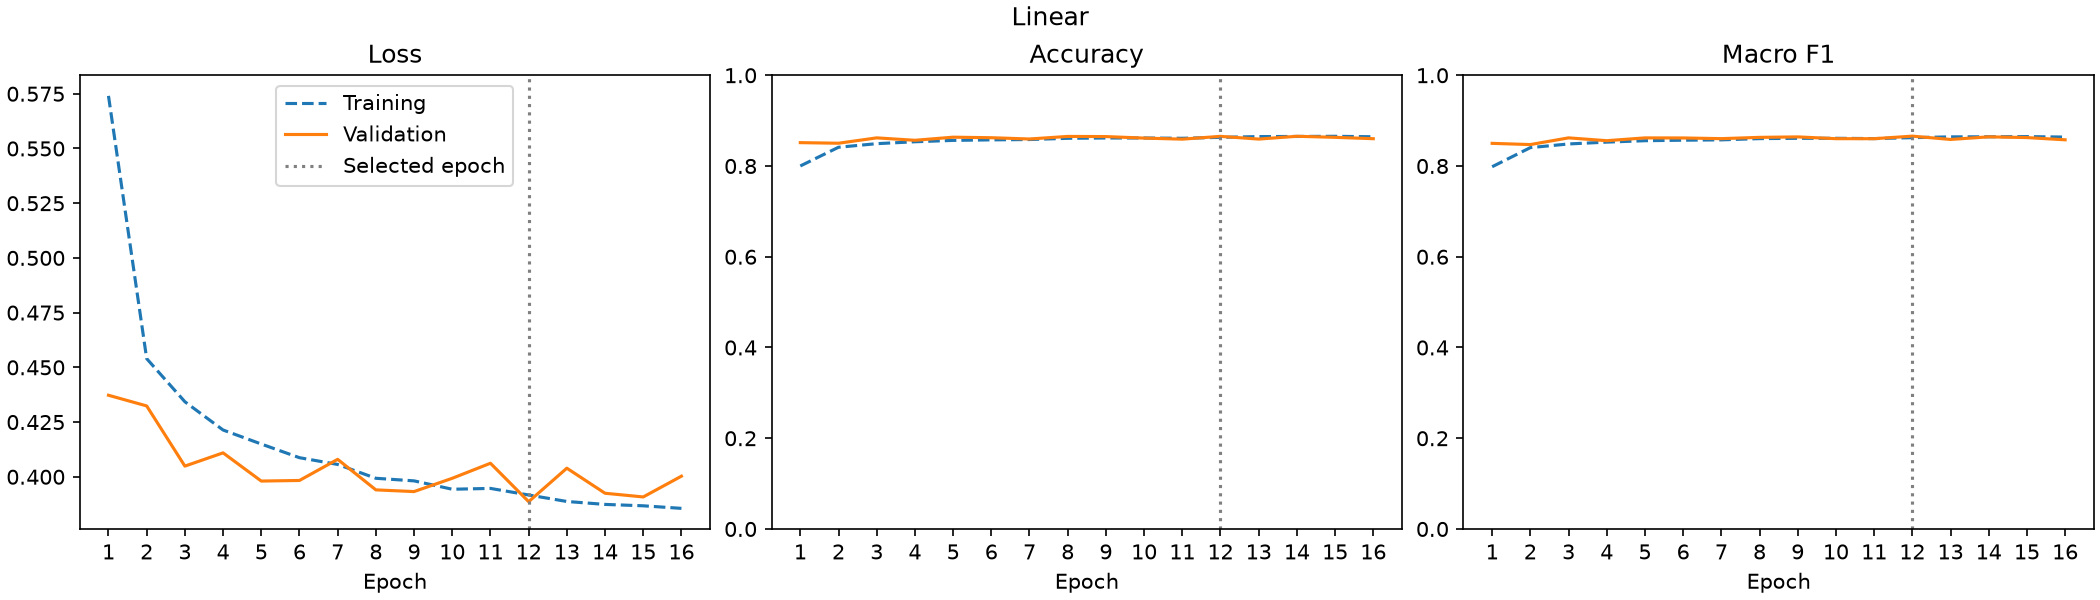

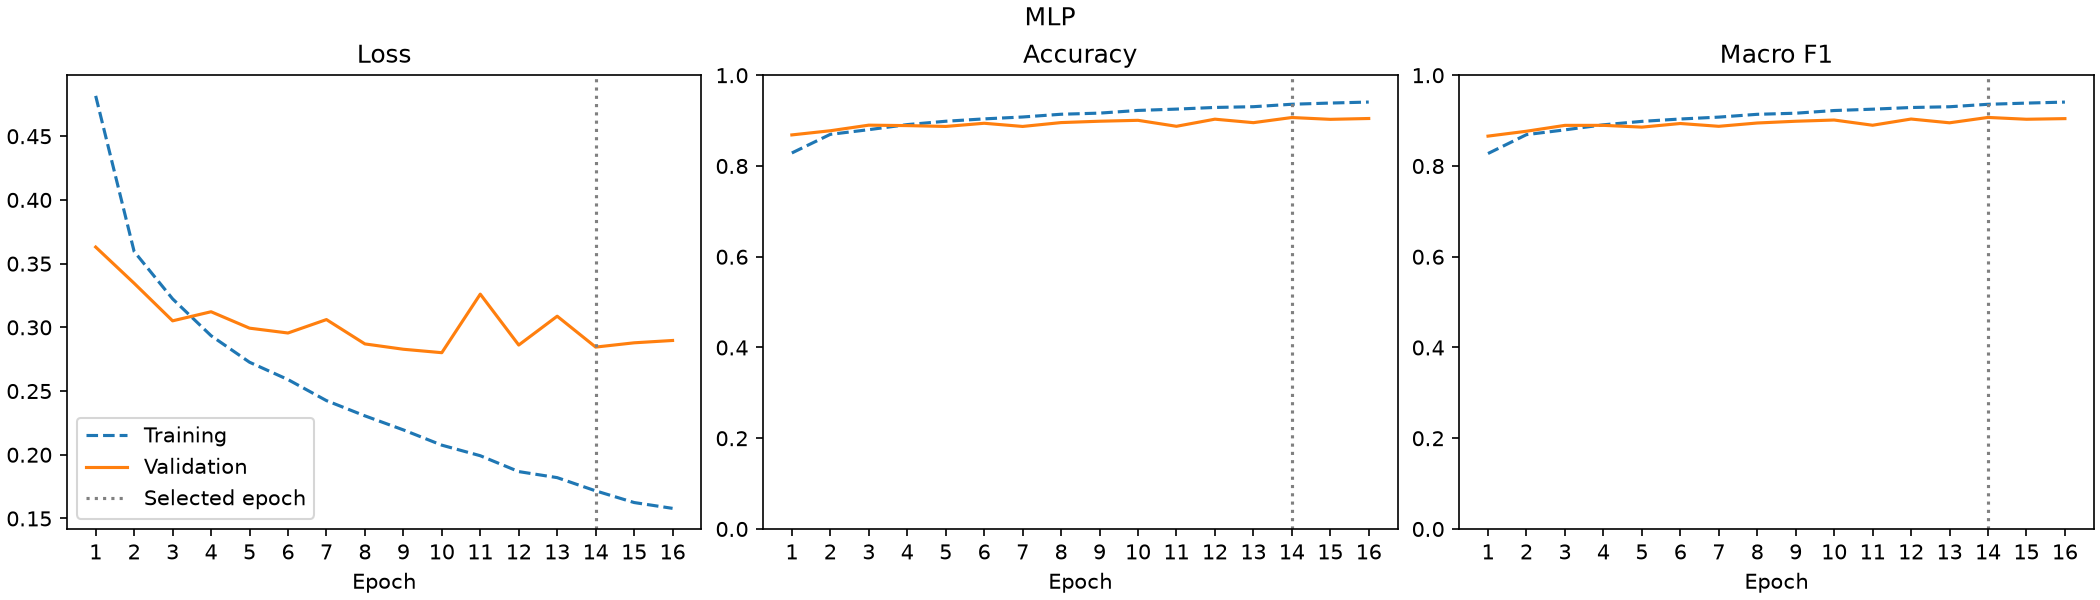

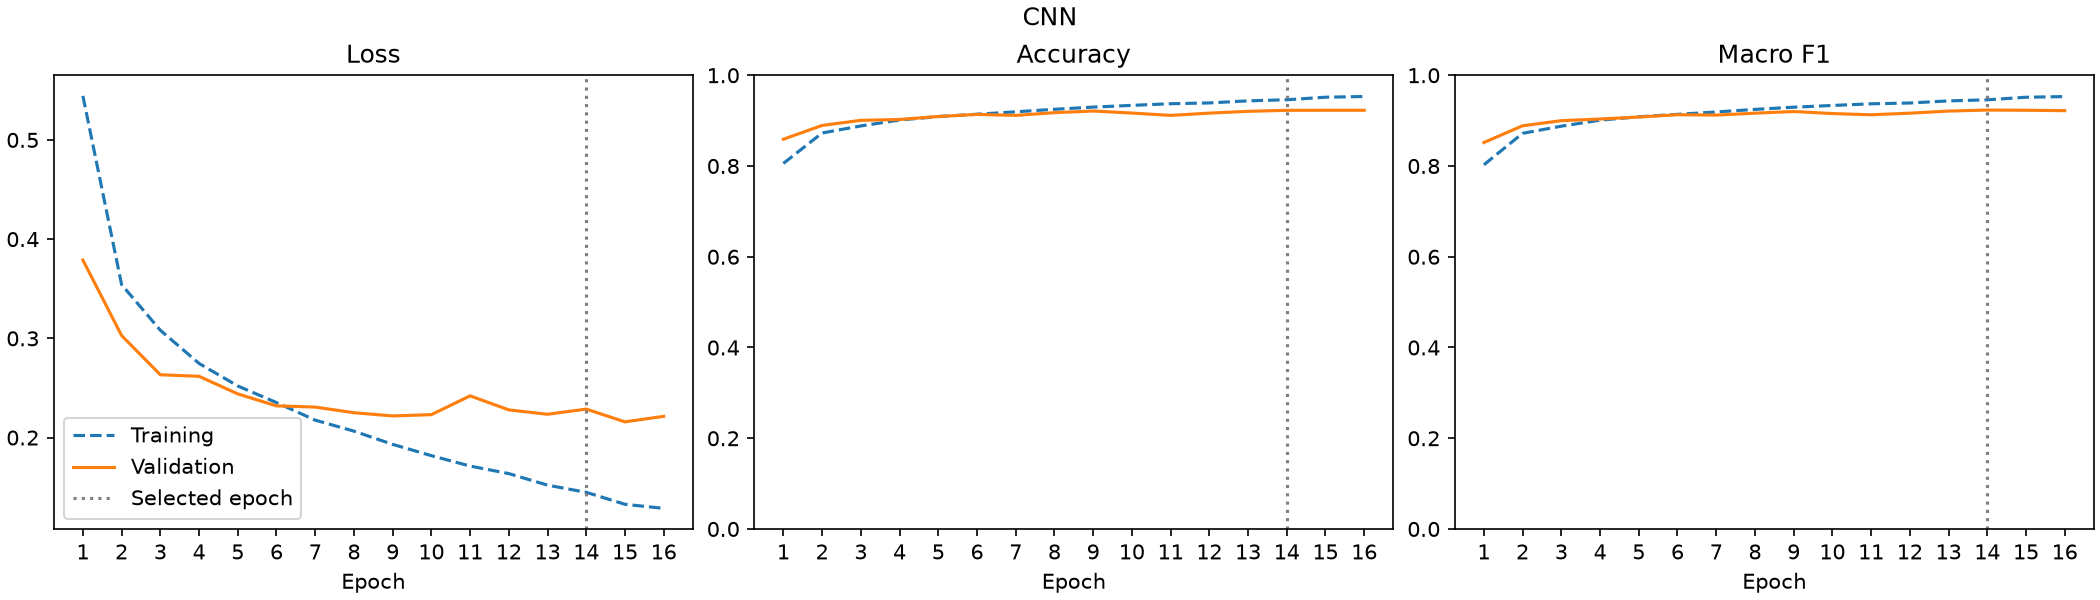

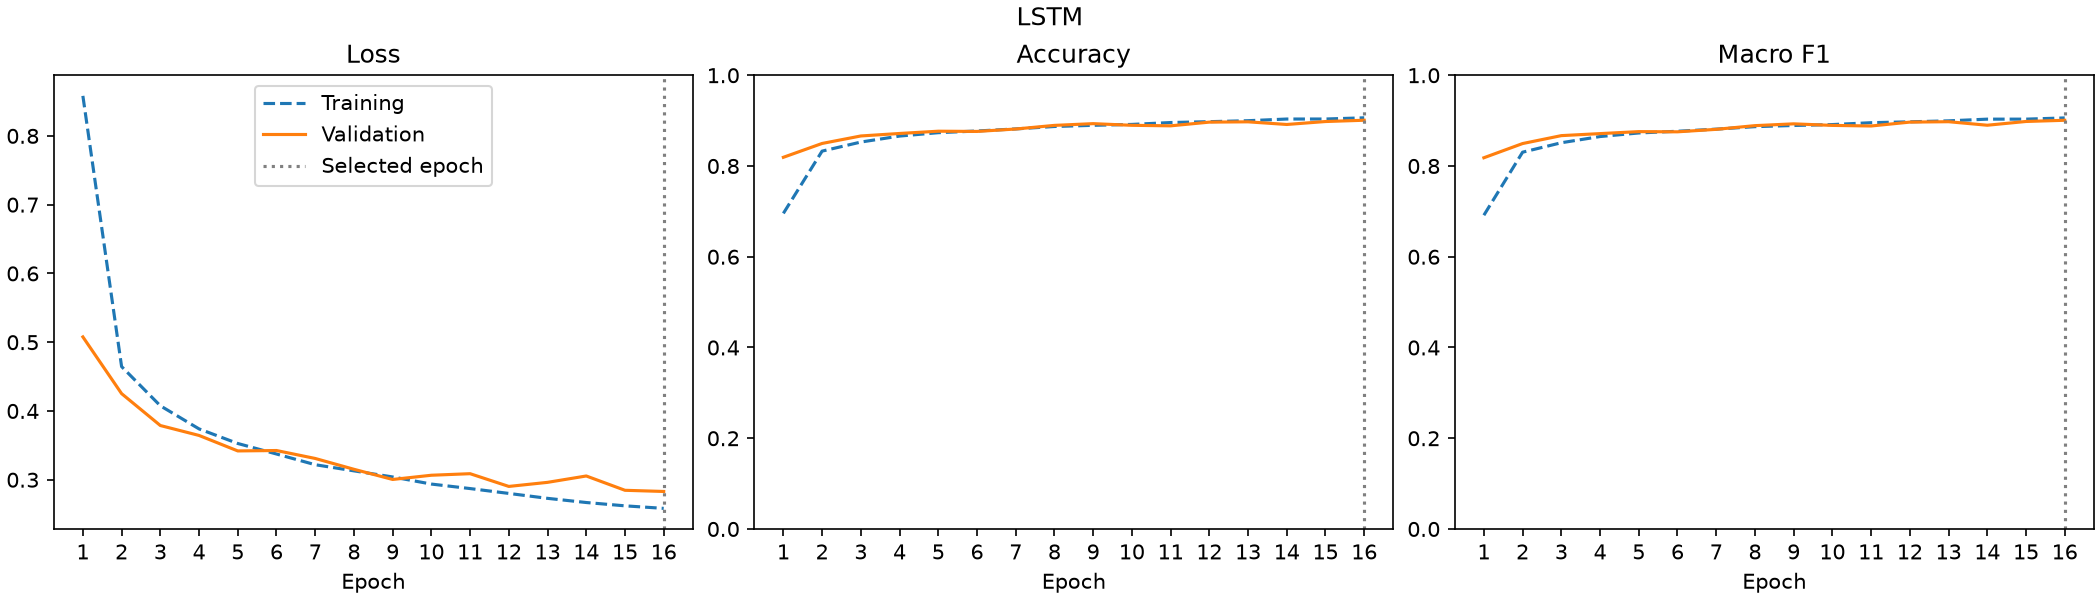

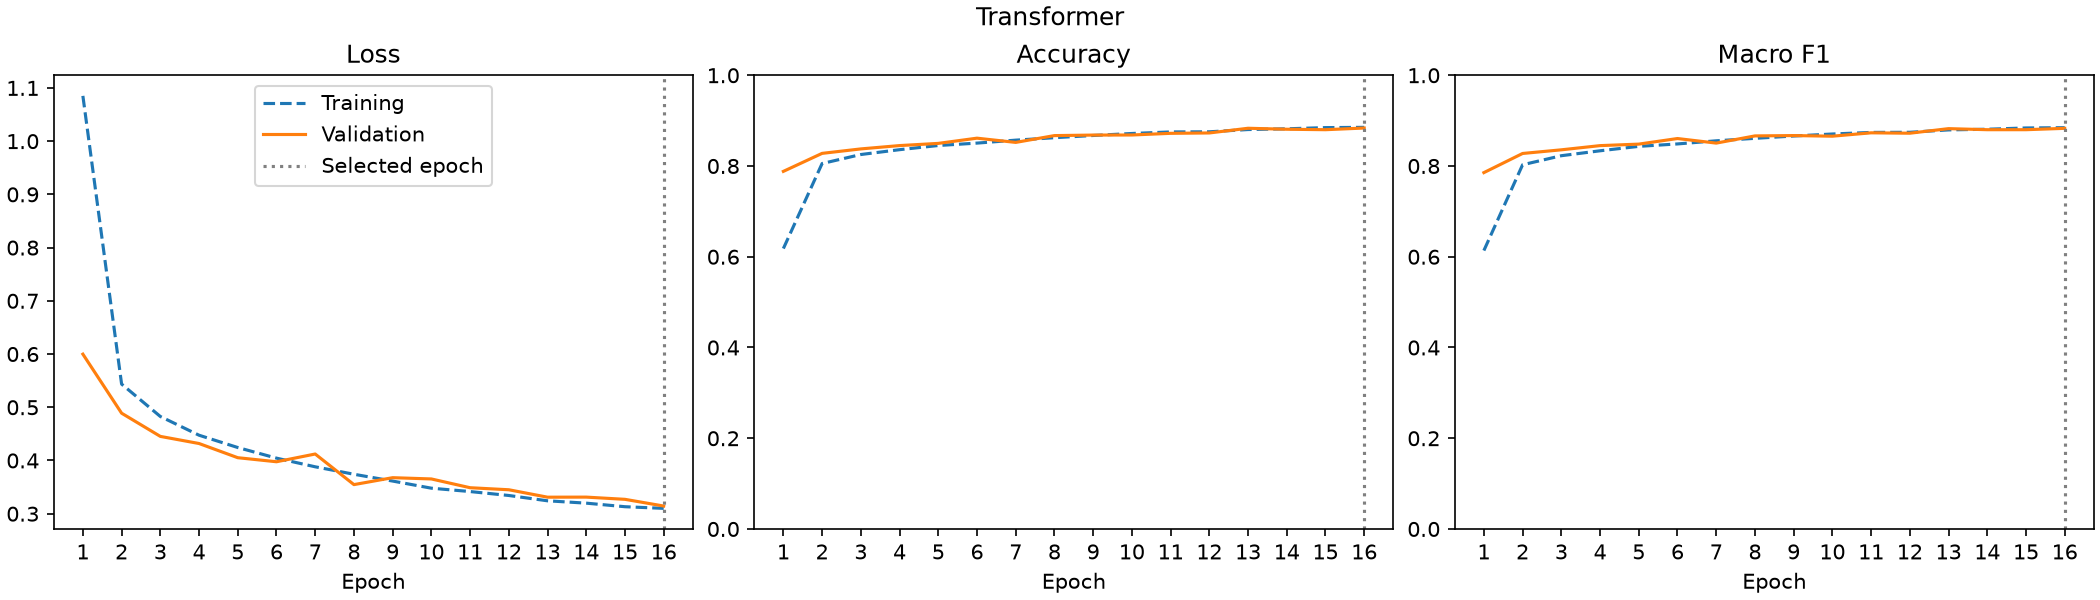

In [7]:
for name, run in training_runs.items():
    display(Image(filename=str(run["folder"] / "learning_curves.png")))

**Observation.** All models complete 16 epochs. Linear selects epoch 12: validation macro-F1 is 0.8658 there and 0.8577 at epoch 16, while validation loss rises from 0.3886 to 0.4003. MLP selects epoch 14; its training loss continues falling while validation loss rises from 0.2845 to 0.2897 by epoch 16. The later weights are not necessarily the better generalizing weights.

CNN also selects epoch 14 even though epoch 16 has slightly lower validation loss and higher accuracy: its macro-F1 falls from 0.9233 to 0.9219. LSTM and Transformer select epoch 16. For Linear, MLP and CNN, `best.pt` and the final `checkpoint.pt` therefore contain weights from different epochs. Evaluation uses the former. Dashed training curves are collected during updates and differ from the fixed-checkpoint training metrics above.

### 4.1 Validation images

Each saved validation file includes all 6,000 raw images with their original training-file IDs, labels, predictions and probabilities. The table counts correct predictions at the selected checkpoint for each model. Change `MODEL`, `START` and `COUNT` to inspect any contiguous page; the default shows the first 16 images for the validation-selected model. Green titles are correct; red titles are incorrect.

In [8]:
validation_predictions = {}
for name, run in training_runs.items():
    with np.load(run["folder"] / "validation_predictions.npz") as saved:
        validation_predictions[name] = {key: saved[key] for key in saved.files}
validation_counts = pd.DataFrame([
    {"model": name, "correct": int((saved["labels"] == saved["predictions"]).sum()),
     "total": len(saved["labels"])}
    for name, saved in validation_predictions.items()
]).set_index("model")
validation_counts["accuracy"] = validation_counts["correct"] / validation_counts["total"]
validation_counts.round(4)

,correct,total,accuracy
model,,,
Linear,5192,6000,0.8653
MLP,5441,6000,0.9068
CNN,5536,6000,0.9227
LSTM,5405,6000,0.9008
Transformer,5302,6000,0.8837


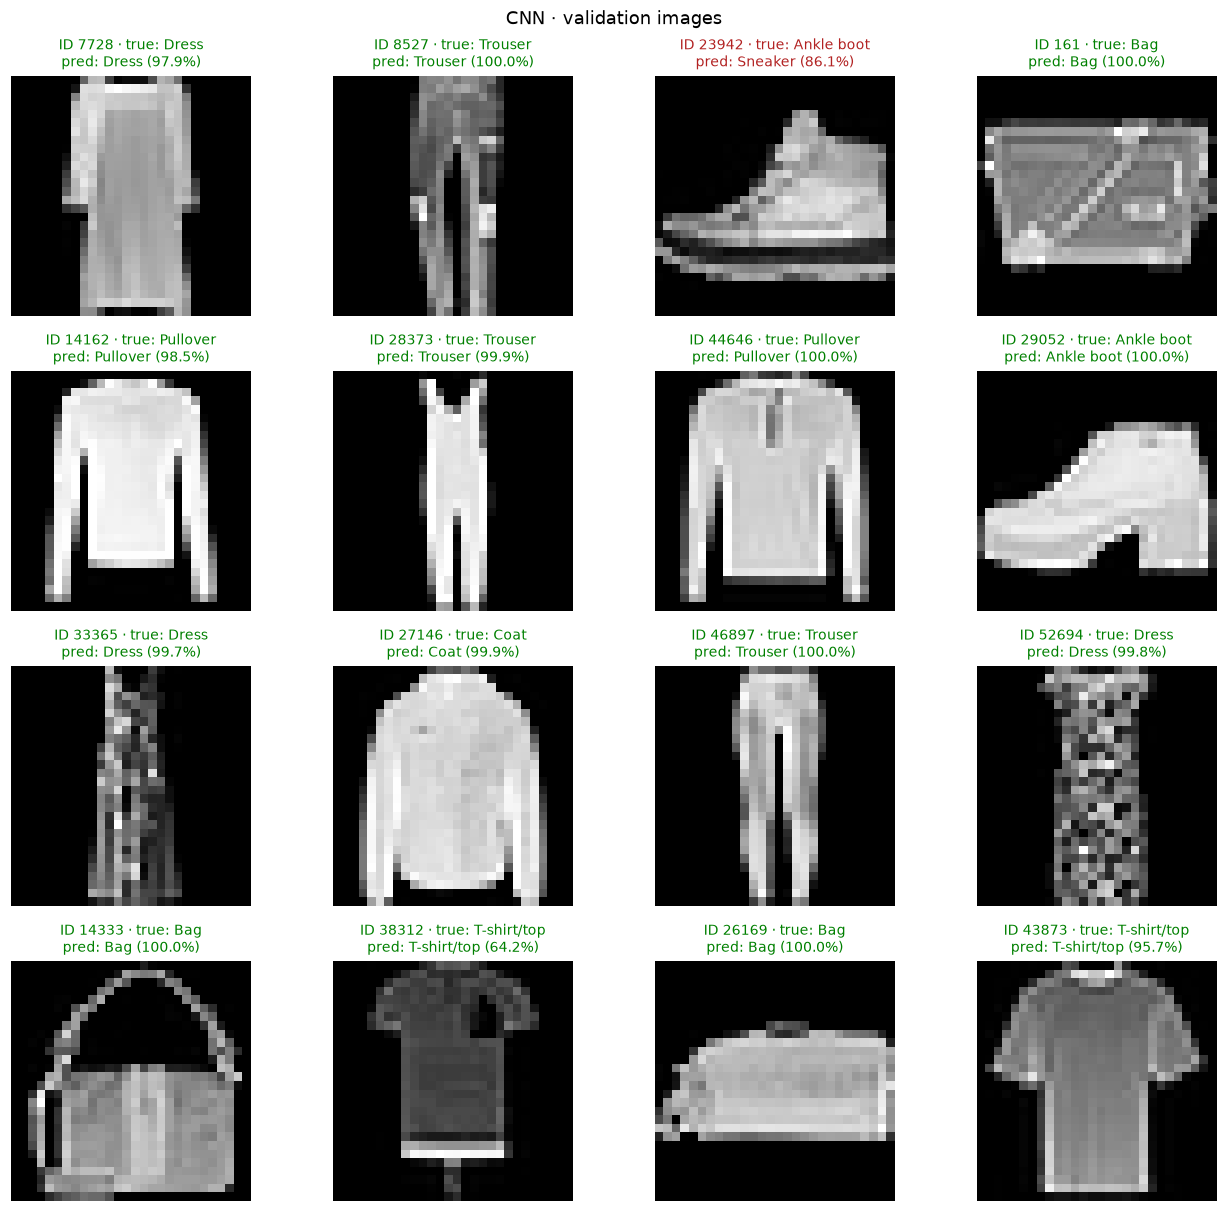

In [9]:
MODEL = training_selected
START = 0
COUNT = 16

saved = validation_predictions[MODEL]
positions = np.arange(START, min(START + COUNT, len(saved["labels"])))
rows = (len(positions) + 3) // 4
fig, axes = plt.subplots(rows, 4, figsize=(12, 2.8 * rows), squeeze=False)
for ax in axes.flat:
    ax.axis("off")
for ax, position in zip(axes.flat, positions):
    true, predicted = saved["labels"][position], saved["predictions"][position]
    confidence = saved["probabilities"][position, predicted]
    index = saved["indices"][position]
    ax.imshow(saved["images"][position], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"ID {index} · true: {NAMES[true]}\npred: {NAMES[predicted]} ({confidence:.1%})",
                 color="green" if true == predicted else "firebrick", fontsize=9)
fig.suptitle(MODEL + " · validation images")
plt.tight_layout()
plt.show()

**Observation.** The displayed CNN page contains 15 correct predictions out of 16. Ankle boot #23942 is predicted as Sneaker with 86.1% confidence, illustrating a confident footwear error even on this mostly correct page. File order determines the examples shown; the table above uses all 6,000 predictions per model and gives CNN 5,536 correct (92.27%).

## 5. Training-seed variability

Use the latest completed run per seed on the shared data split. Sample standard deviation needs at least two distinct seeds. It measures training variability on this split, not uncertainty across datasets.

In [10]:
seed_scores = pd.DataFrame([
    {"model": name, "seed": seed, "accuracy": run["validation"]["accuracy"],
     "macro_f1": run["validation"]["macro_f1"]}
    for (name, seed), run in runs.items()
])
summary = seed_scores.groupby("model", sort=False).agg(
    runs=("seed", "count"), accuracy_mean=("accuracy", "mean"),
    accuracy_sd=("accuracy", "std"), macro_f1_mean=("macro_f1", "mean"),
    macro_f1_sd=("macro_f1", "std")
)
display(seed_scores.round(4))
display(summary.round(4).fillna("SD unavailable"))

,model,seed,accuracy,macro_f1
0,Linear,42,0.8653,0.8658
1,MLP,42,0.9068,0.9070
2,CNN,42,0.9227,0.9233
3,LSTM,42,0.9008,0.9007
4,Transformer,42,0.8837,0.8830


,runs,accuracy_mean,accuracy_sd,macro_f1_mean,macro_f1_sd
model,,,,,
Linear,1,0.8653,SD unavailable,0.8658,SD unavailable
MLP,1,0.9068,SD unavailable,0.9070,SD unavailable
CNN,1,0.9227,SD unavailable,0.9233,SD unavailable
LSTM,1,0.9008,SD unavailable,0.9007,SD unavailable
Transformer,1,0.8837,SD unavailable,0.8830,SD unavailable


**Observation.** Every model has exactly one evaluated training seed, 42. The reported mean equals that run's score, and sample standard deviation is unavailable. No conclusion about training-seed stability or statistical significance follows from this batch; the next reproducibility check is to repeat the unchanged setup with additional seeds.

## 6. Test confusion matrices

Rows are true classes; columns are predictions. Cell counts show how often each decision occurs. Compare clothing confusions with the visual similarities observed in EDA.

In [11]:
predictions = {}
for name, run in primary.items():
    with np.load(run["folder"] / "test_predictions.npz") as saved:
        predictions[name] = {key: saved[key] for key in saved.files}
confusions = {
    name: confusion_matrix(saved["labels"], saved["predictions"], labels=range(10))
    for name, saved in predictions.items()
}
pd.Series({name: len(saved["labels"]) for name, saved in predictions.items()}, name="Test images")

Linear         10000
MLP            10000
CNN            10000
LSTM           10000
Transformer    10000
Name: Test images, dtype: int64

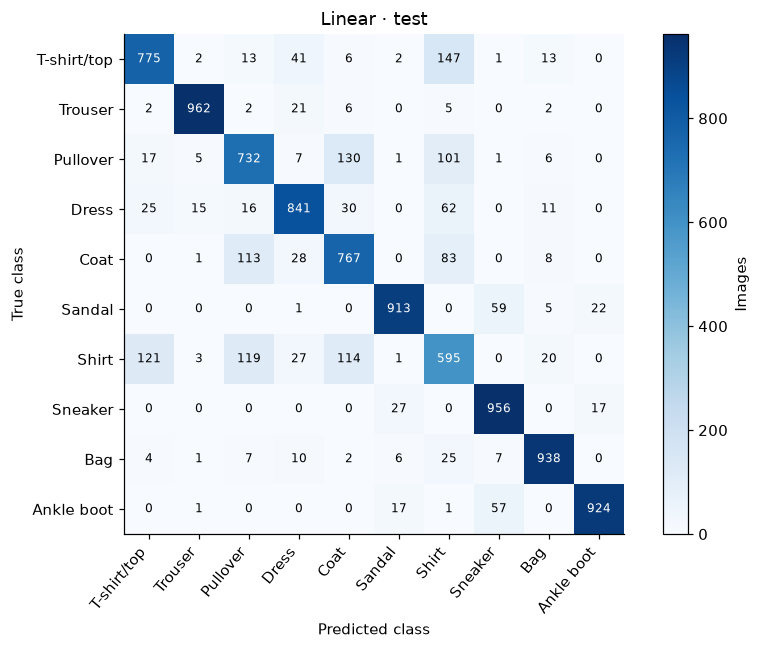

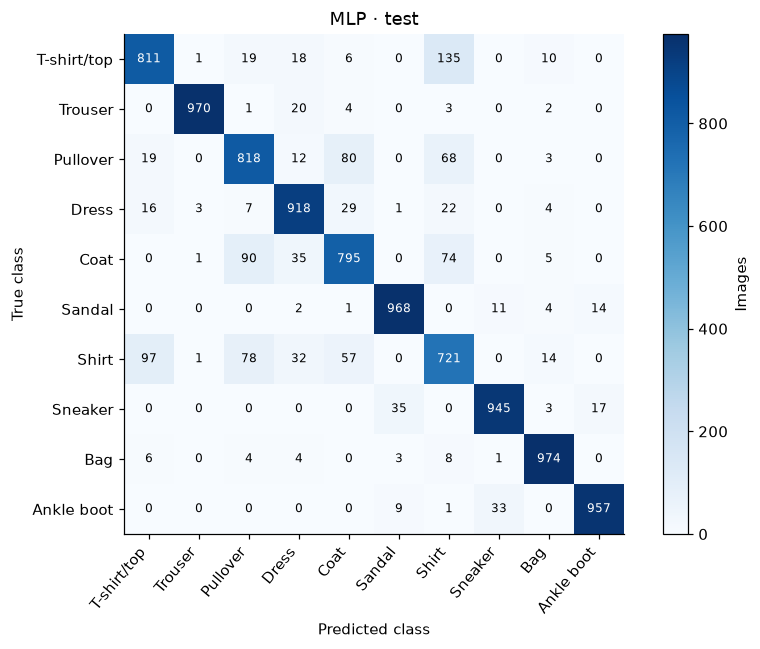

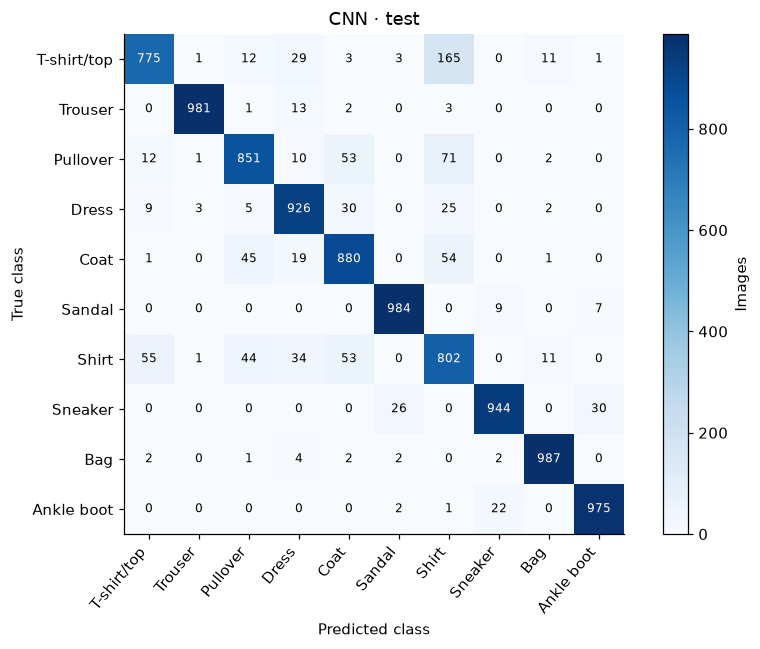

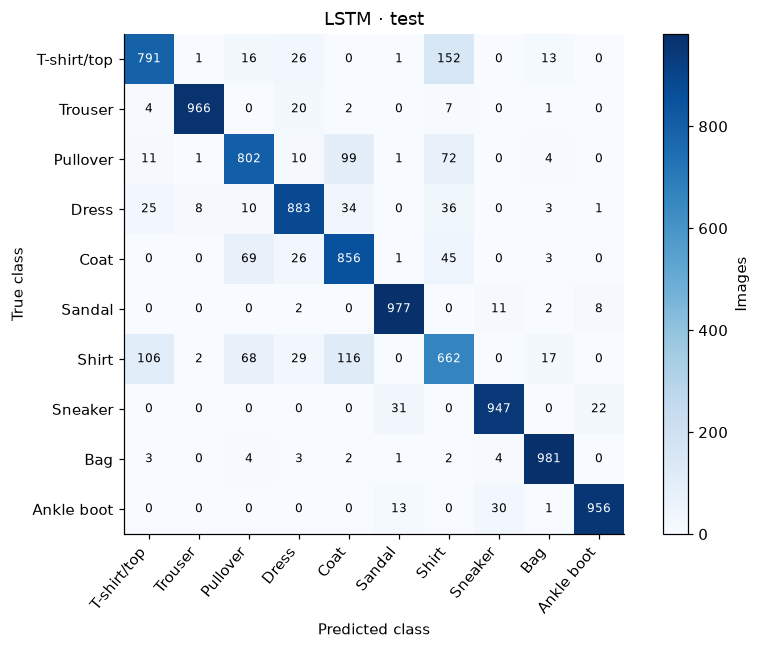

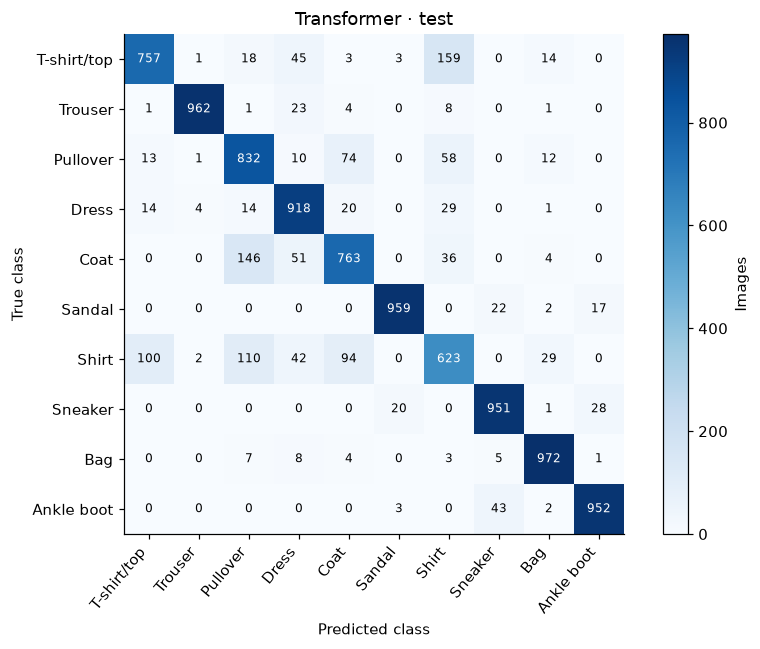

In [12]:
for name, matrix in confusions.items():
    fig, ax = plt.subplots(figsize=(8, 6))
    image = ax.imshow(matrix, cmap="Blues", vmin=0)
    for true in range(10):
        for predicted in range(10):
            ax.text(predicted, true, matrix[true, predicted], ha="center", va="center",
                    color="white" if matrix[true, predicted] > matrix.max() / 2 else "black", fontsize=8)
    ax.set_xticks(range(10), NAMES, rotation=50, ha="right")
    ax.set_yticks(range(10), NAMES)
    ax.set(title=name + " · test", xlabel="Predicted class", ylabel="True class")
    fig.colorbar(image, ax=ax, label="Images")
    plt.tight_layout()
    plt.show()

**Observation.** All five models make substantial mistakes among T-shirt/top, Shirt, Pullover and Coat. This supports the EDA hypothesis that similar upper-body silhouettes create ambiguity. CNN reduces Pullover → Coat errors from Linear's 130 to 53, but its largest error is T-shirt/top → Shirt, with 165 cases. Better overall performance does not improve every class pair: MLP makes 135 errors in that direction.

Each true class contains 1,000 test images, so the displayed counts also convert directly to within-class percentages by dividing by ten. Shirt can attract many false positives even when true shirts are recognized correctly.

,Linear,MLP,CNN,LSTM,Transformer
T-shirt/top,0.797,0.832,0.836,0.815,0.803
Trouser,0.967,0.982,0.987,0.977,0.977
Pullover,0.731,0.811,0.869,0.815,0.782
Dress,0.851,0.900,0.910,0.883,0.876
Coat,0.746,0.806,0.870,0.812,0.778
Sandal,0.928,0.960,0.976,0.965,0.966
Shirt,0.589,0.710,0.756,0.670,0.650
Sneaker,0.919,0.950,0.955,0.951,0.941
Bag,0.937,0.965,0.980,0.969,0.954
Ankle boot,0.941,0.963,0.969,0.962,0.953


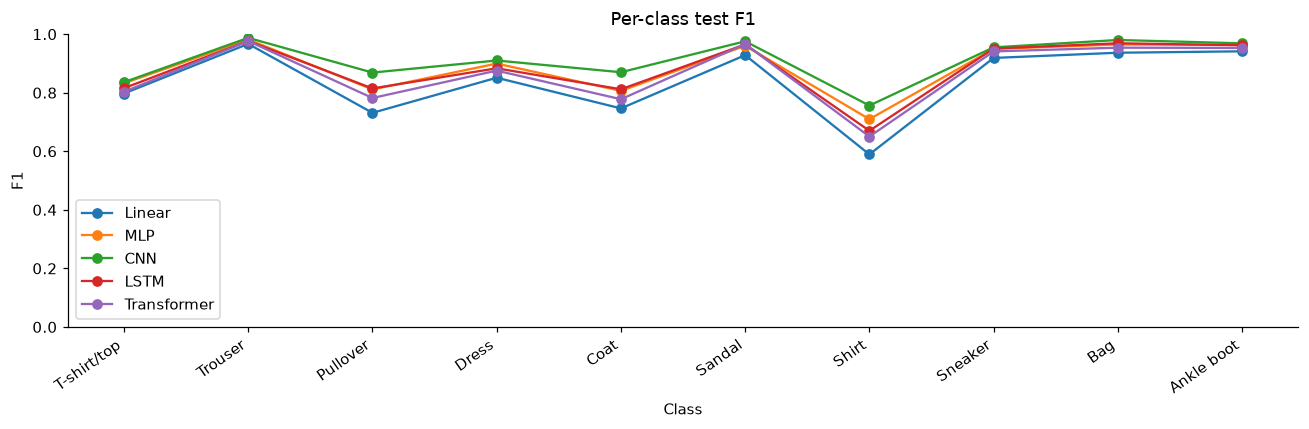

In [13]:
class_f1 = pd.DataFrame({
    name: f1_score(saved["labels"], saved["predictions"], labels=range(10), average=None, zero_division=0)
    for name, saved in predictions.items()
}, index=NAMES)
display(class_f1.round(3))
ax = class_f1.plot(marker="o", figsize=(12, 4))
ax.set(xlabel="Class", ylabel="F1", title="Per-class test F1", ylim=(0, 1))
ax.set_xticks(range(10), NAMES, rotation=35, ha="right")
plt.tight_layout()
plt.show()

**Observation.** Shirt is the weakest class for every model: F1 ranges from **0.589** for Linear to **0.756** for CNN. CNN's Trouser F1 is **0.987** and Bag F1 is **0.980**, showing how much the difficulty varies despite equal class counts. CNN improves Shirt F1 over MLP's 0.710, but substantial overlap among upper-body garments remains. Macro-F1 retains that weak class's contribution instead of reporting only the overall success rate.

In [14]:
errors = []
for name, matrix in confusions.items():
    off_diagonal = matrix.copy()
    np.fill_diagonal(off_diagonal, 0)
    for position in np.argsort(-off_diagonal.ravel(), kind="stable")[:5]:
        true, predicted = divmod(int(position), 10)
        count = int(off_diagonal[true, predicted])
        if count:
            errors.append({"model": name, "true": NAMES[true], "predicted": NAMES[predicted],
                           "count": count, "class_error_rate": count / matrix[true].sum()})
pd.DataFrame(errors).round(4)

,model,true,predicted,count,class_error_rate
0,Linear,T-shirt/top,Shirt,147,0.147
1,Linear,Pullover,Coat,130,0.130
2,Linear,Shirt,T-shirt/top,121,0.121
3,Linear,Shirt,Pullover,119,0.119
4,Linear,Shirt,Coat,114,0.114
5,MLP,T-shirt/top,Shirt,135,0.135
6,MLP,Shirt,T-shirt/top,97,0.097
7,MLP,Coat,Pullover,90,0.090
8,MLP,Pullover,Coat,80,0.080
9,MLP,Shirt,Pullover,78,0.078


**Observation.** CNN's five most frequent directional errors are T-shirt/top → Shirt (165; 16.5% of true T-shirts), Pullover → Shirt (71), Shirt → T-shirt/top (55), Coat → Shirt (54) and Pullover → Coat (53). Four of these five involve Shirt. The reverse Shirt → T-shirt/top direction is much less frequent than T-shirt/top → Shirt, so treating the pair as a symmetric error would hide useful information.

## 7. Inspect predictions

For each model, show four correct predictions in test-file order, four lowest-confidence correct predictions, and four incorrect predictions in test-file order. Confidence is the largest softmax probability; it is not a calibrated guarantee. IDs refer to the official test image file.

In [15]:
raw = ROOT.parent / "data" / "FashionMNIST" / "raw"
images = np.fromfile(raw / "t10k-images-idx3-ubyte", dtype=np.uint8, offset=16).reshape(-1, 28, 28)
galleries = {}
for name, saved in predictions.items():
    confidence = saved["probabilities"].max(axis=1)
    correct = np.flatnonzero(saved["labels"] == saved["predictions"])
    incorrect = np.flatnonzero(saved["labels"] != saved["predictions"])
    difficult = correct[np.argsort(confidence[correct], kind="stable")[:4]]
    galleries[name] = {"Correct": correct[:4], "Difficult correct": difficult, "Incorrect": incorrect[:4]}
print("Test images:", images.shape)

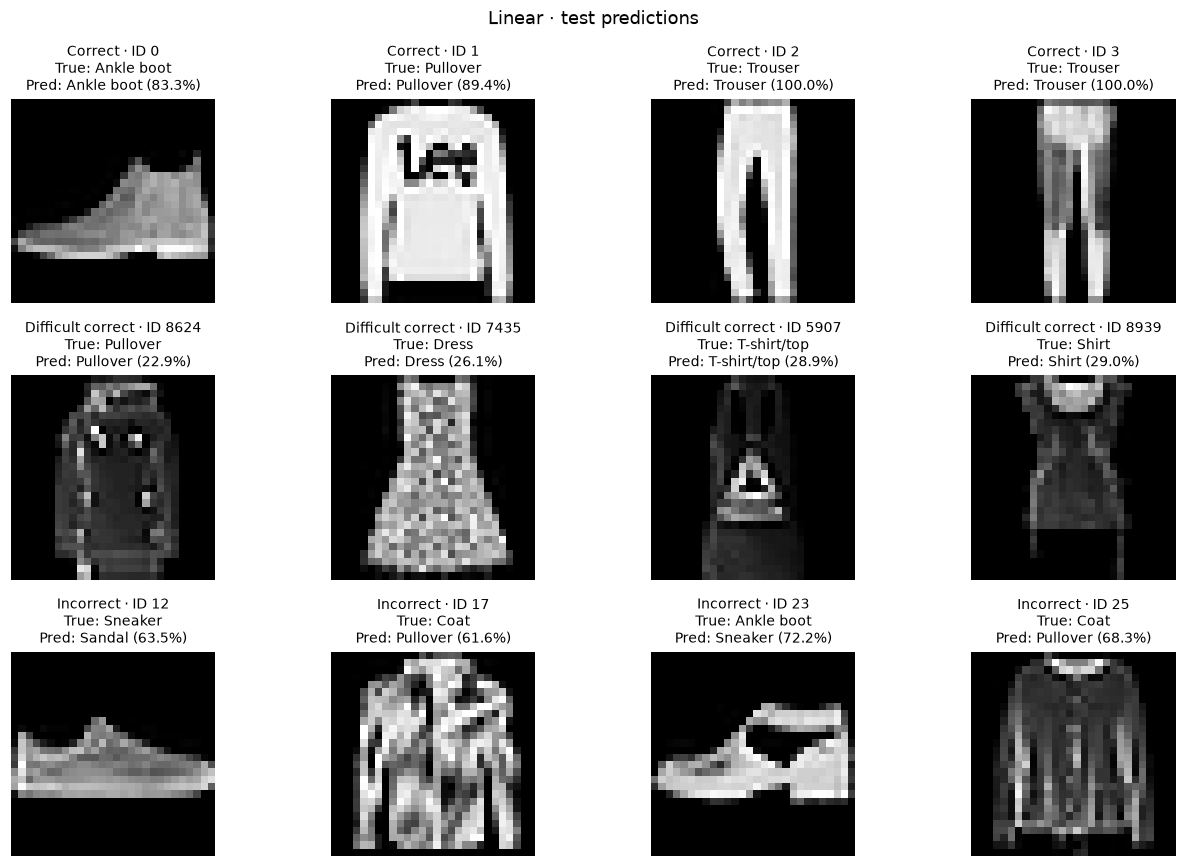

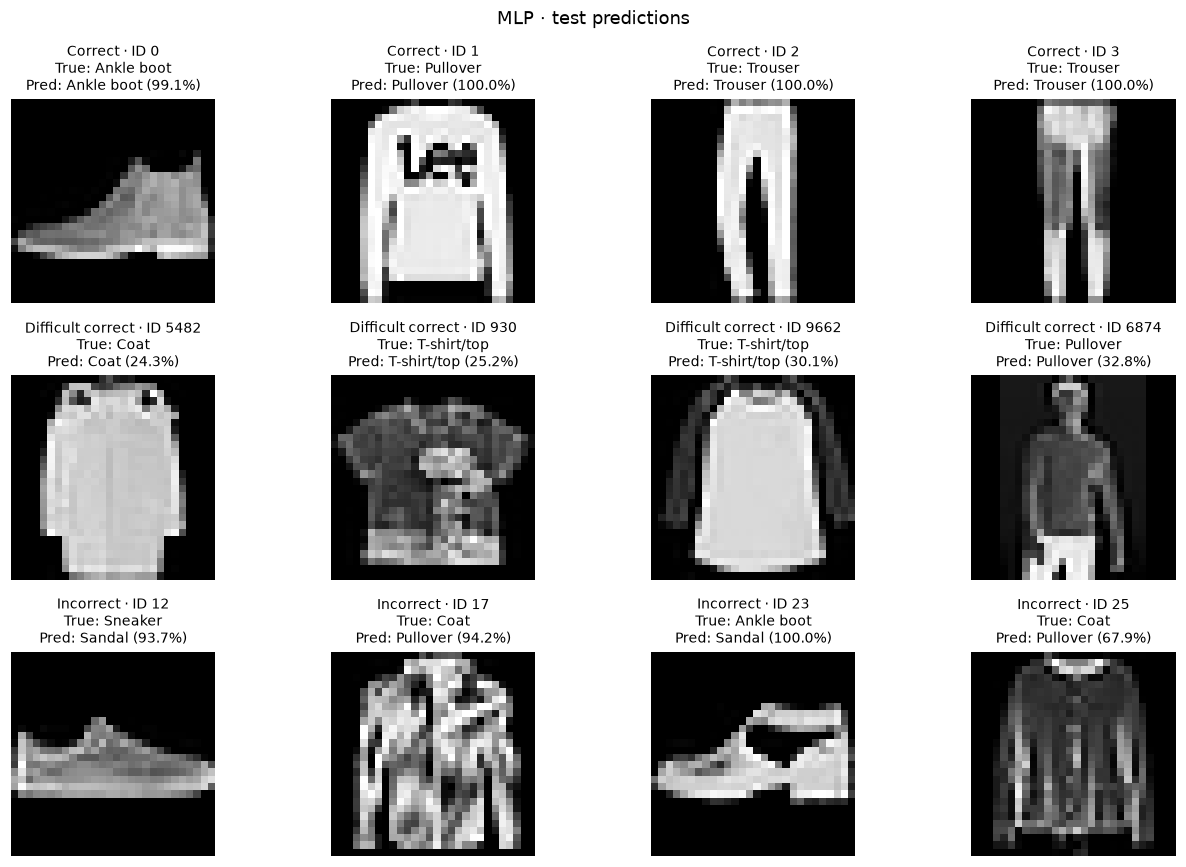

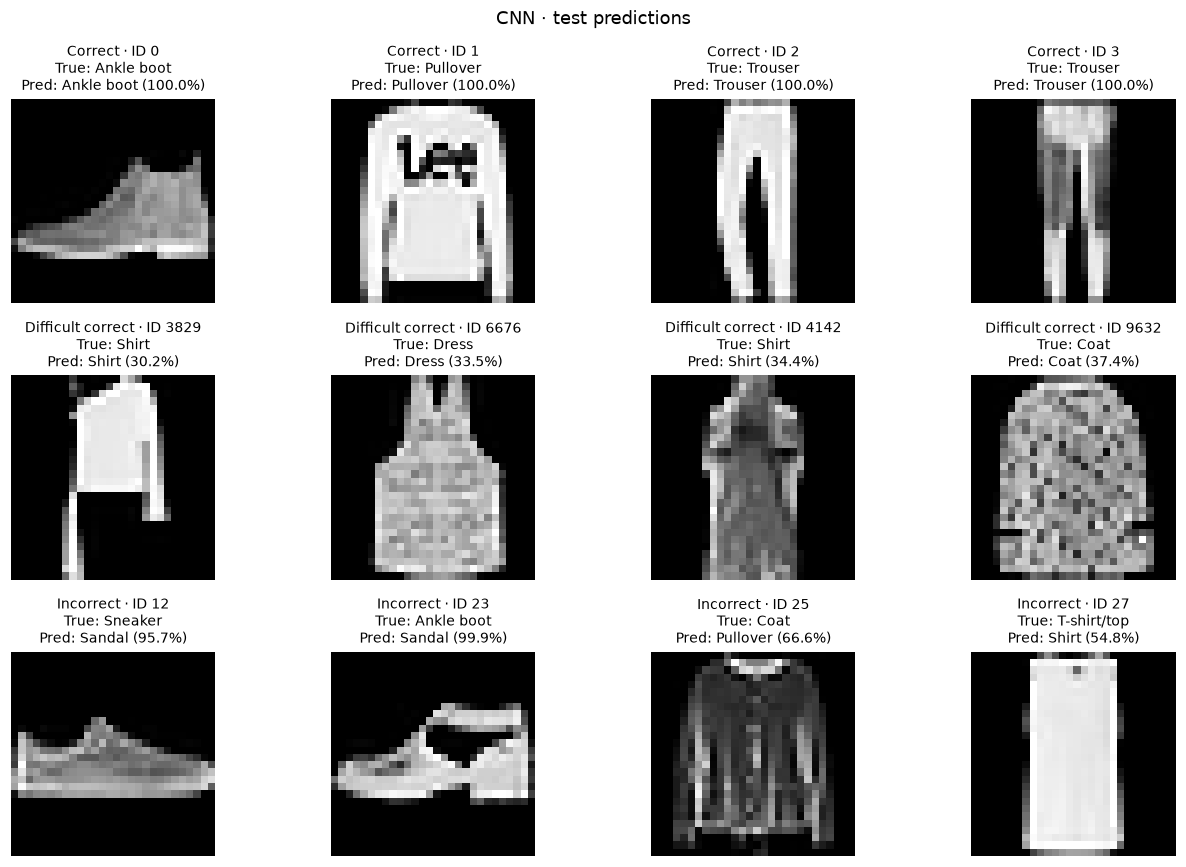

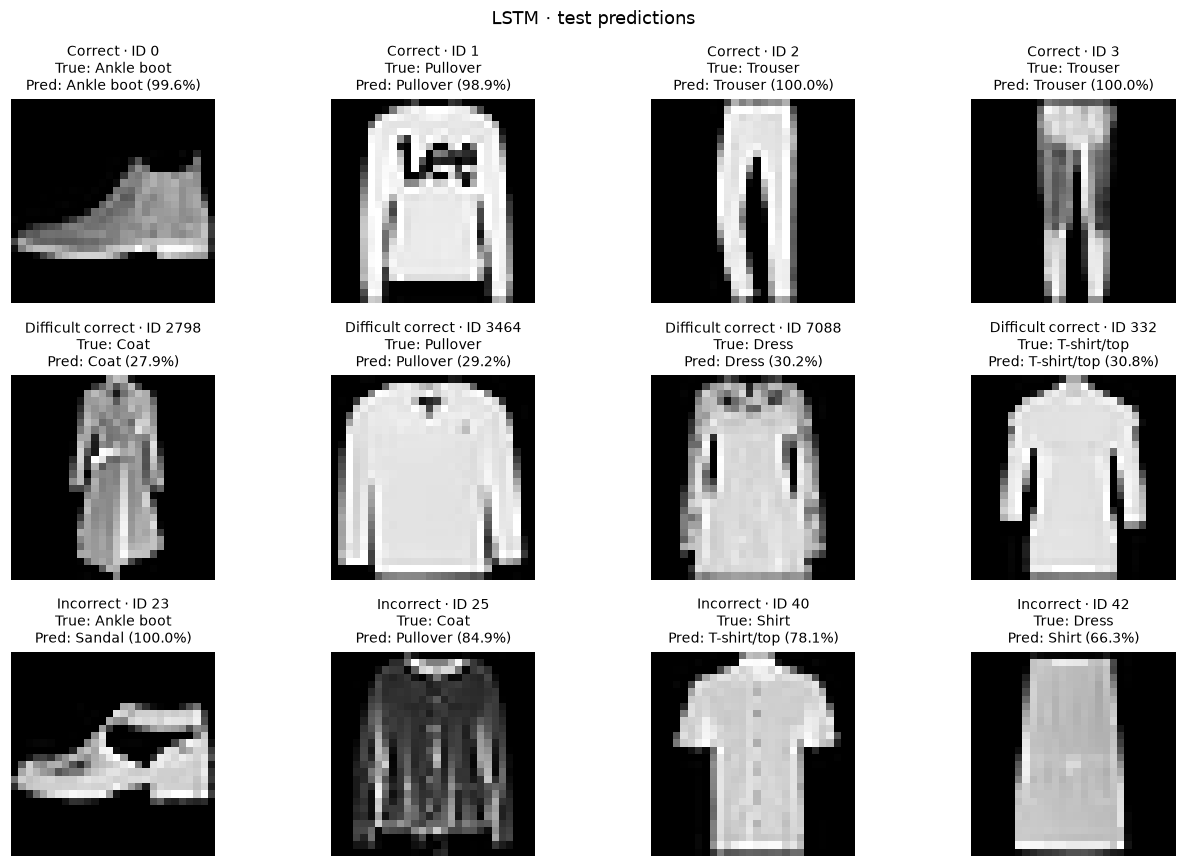

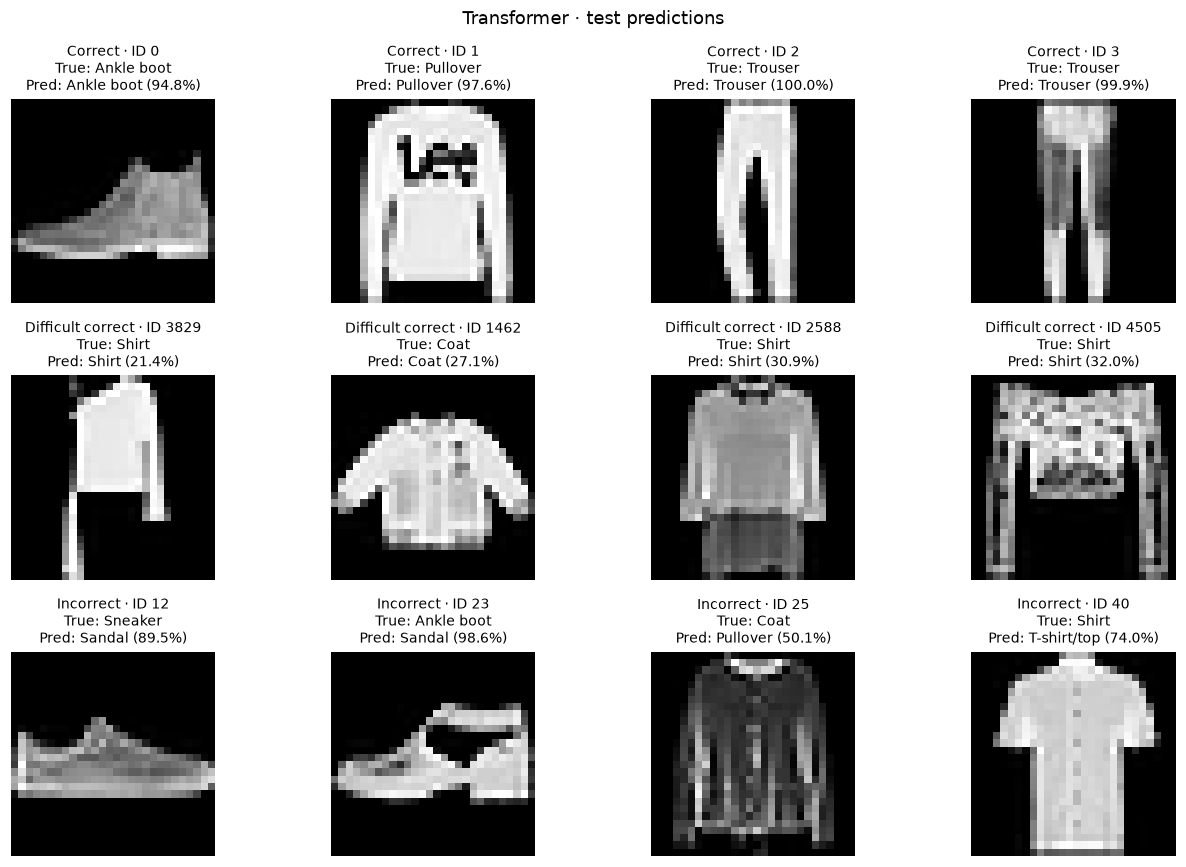

In [16]:
for name, groups in galleries.items():
    saved = predictions[name]
    fig, axes = plt.subplots(3, 4, figsize=(12, 8), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for row, (kind, positions) in enumerate(groups.items()):
        for ax, position in zip(axes[row], positions):
            index = saved["indices"][position]
            true, predicted = saved["labels"][position], saved["predictions"][position]
            confidence = saved["probabilities"][position, predicted]
            ax.imshow(images[index], cmap="gray", vmin=0, vmax=255)
            ax.set_title(f"{kind} · ID {index}\nTrue: {NAMES[true]}\nPred: {NAMES[predicted]} ({confidence:.1%})", fontsize=9)
    fig.suptitle(name + " · test predictions")
    plt.tight_layout()
    plt.show()

**Observation.** CNN correctly recognizes the first boot, printed pullover and two trousers, whose broad silhouettes are visible. Its low-confidence correct cases include Shirt #3829 at 30.2% and Dress #6676 at 33.5%; the pictured garments have unusual or indistinct outlines. They show that a correct class can win with low confidence.

CNN misclassifies Sneaker #12 as Sandal at 95.7% and Ankle boot #23 as Sandal at 99.9%. The latter image has a heel and large dark opening, giving it features that resemble a sandal despite its supplied label. Transformer makes the same two footwear mistakes, at 89.5% and 98.6%. CNN also labels dark Coat #25 as Pullover and sleeveless T-shirt #27 as Shirt. These examples illustrate visual ambiguity without establishing that the dataset labels are wrong.

Transformer's lowest-confidence correct example is the same asymmetric Shirt #3829, at 21.4%. Its difficult group also contains Coat #1462 at 27.1%, a short garment with a front opening, and two other shirts. All four are upper-body garments with features shared across categories. Softmax confidence can be high on mistakes and low on correct decisions. The first four errors are a deterministic inspection sample, not a representative estimate of the overall error distribution.

## 8. Discussion

The 256-unit MLP adds nonlinear features to the flattened 784-pixel representation and improves test accuracy from **84.03% to 88.77%** over Linear. Both lose explicit two-dimensional neighborhood structure, but the MLP can combine pixels nonlinearly. The models also differ in parameter count and computation, so the comparison does not isolate nonlinearity as the sole cause of the gain.

**CNN is the validation-selected candidate.** Its local 3 × 3 filters and pooling exploit spatial structure, reaching **91.05% test accuracy** and **0.9108 macro-F1**. Against MLP it gains 2.28 accuracy points with roughly half as many parameters, at about 14 times the measured batched CPU inference time per image. CNN is the stronger accuracy choice here; MLP offers a useful inference-cost trade-off. The sequential fit takes 151.30 s for CNN versus 11.88 s for MLP over the same 16-epoch budget; inference and training costs should be assessed separately.

LSTM reads 28 image rows sequentially and summarizes them in a final hidden state. It reaches **88.21%** test accuracy with 24,714 parameters, but is slower at inference than MLP and reaches its best validation result only at the 16-epoch limit. Transformer attends over 49 patches of 4 × 4 pixels with learned positions, reaching **86.89%** with 19,530 parameters. These compact sequence models have different spatial assumptions and optimization needs; their current scores do not show that sequence models cannot learn images or that more training must improve them.

The persistent limitation is upper-body clothing ambiguity. Shirt remains CNN's weakest class, and **165 true T-shirts are predicted as shirts**. The inspected footwear mistakes also show that high softmax confidence does not guarantee a correct label. This links the result analysis back to EDA's overlapping silhouettes while keeping descriptive image similarity separate from measured classification errors.

First repeat the unchanged setup with additional seeds. Then use training and validation to test a longer LSTM training budget and modest image shifts or weight decay for the nonlinear models. These are proposed experiments, not measured improvements; their settings should not be chosen from test performance. The current comparison uses one split, one training seed and a fixed 16-epoch budget, with no architecture-specific tuning.